# Chapter 56 — Visualizing Functions

> **Prerequisites:** ch051–055 (Function foundations)
>
> **You will learn:**
> - Use matplotlib to visualize any function on a given domain
> - Compare multiple functions in the same plot
> - Identify key features: zeros, extrema, asymptotes visually
> - Build a reusable function plotter
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Visualization is not decoration — it is the fastest way to build intuition about a function's behavior. Before computing anything analytically, plot it. The shape of a function reveals its zeros, monotonicity, asymptotes, growth rate, and periodicity at a glance.

A well-made function plot answers: where is f(x) = 0? Where is f increasing? Does it blow up? Does it repeat? These questions take pages of algebra but seconds of visual inspection.

---

## 2. Intuition & Mental Models

**Physical analogy:** A map is a visualization of a geographic function. The terrain shape is immediately obvious from contour lines — it would take hours to understand from a table of coordinates.

**Computational analogy:** A debugger's watch variable is like reading a function table. A plot is like running a profiler — you see the whole picture at once.

Recall from ch008 (Visualization as a Learning Tool): the purpose of a plot is to reveal structure, not just to display data. Every axis label, grid line, and color choice is a communication decision.

---

## 3. Visualization

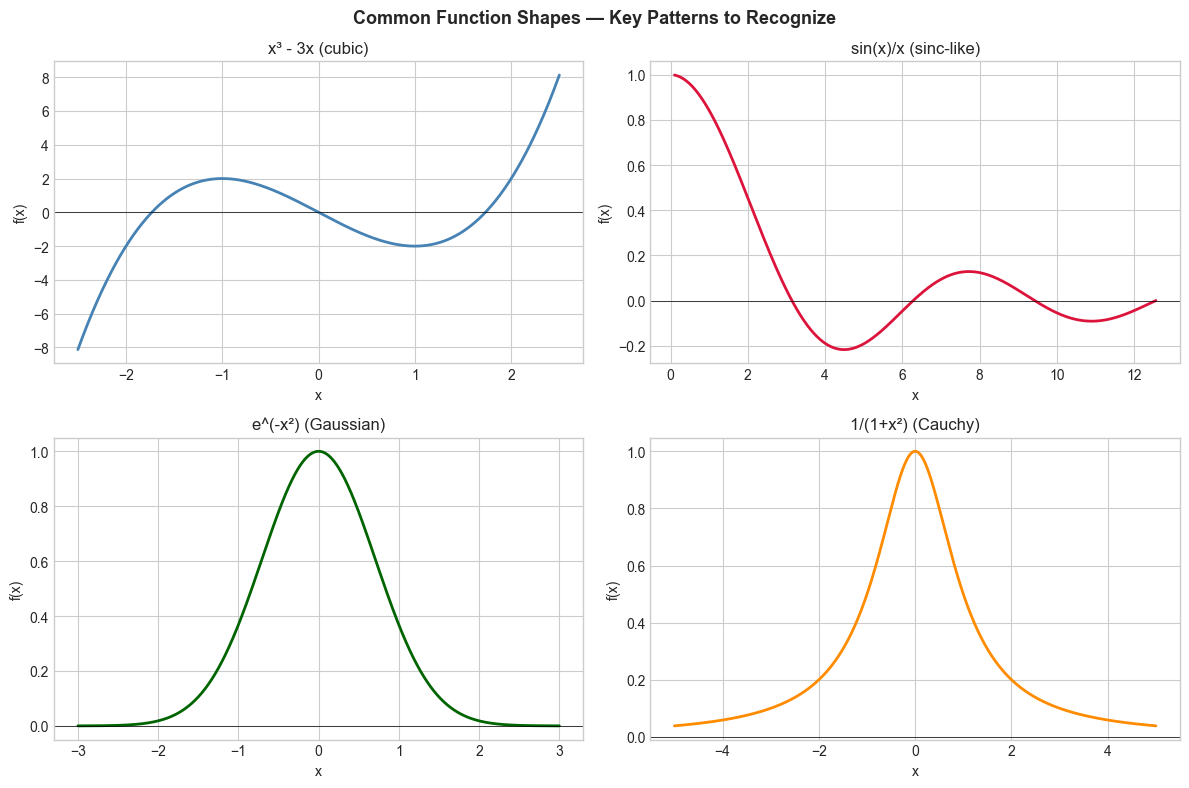

In [1]:
# --- Visualization: Multi-panel function explorer ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def plot_function(f, x_min, x_max, ax, label, color='steelblue', n=1000):
    """Plot a function with zeros and extrema annotated."""
    x = np.linspace(x_min, x_max, n)
    y = f(x)
    ax.plot(x, y, color=color, linewidth=2, label=label)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

funcs = [
    (lambda x: x**3 - 3*x, -2.5, 2.5, 'x³ - 3x (cubic)'),
    (lambda x: np.sin(x) / x if True else None, 0.1, 4*np.pi, 'sin(x)/x (sinc-like)'),
    (lambda x: np.exp(-x**2), -3, 3, 'e^(-x²) (Gaussian)'),
    (lambda x: 1/(1 + x**2), -5, 5, '1/(1+x²) (Cauchy)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['steelblue', 'crimson', 'darkgreen', 'darkorange']

for ax, (f, a, b, label), color in zip(axes.flat, funcs, colors):
    x = np.linspace(a, b, 1000)
    with np.errstate(invalid='ignore', divide='ignore'):
        y = f(x)
    ax.plot(x, np.where(np.isfinite(y), y, np.nan), color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')

plt.suptitle('Common Function Shapes — Key Patterns to Recognize', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

Key visual features to identify:
- **Zeros:** where f(x) = 0 — the x-intercepts
- **Extrema:** local maxima and minima
- **Asymptotes:** vertical (where f→∞), horizontal (limiting value)
- **Monotonicity:** where f is increasing vs decreasing
- **Symmetry:** even (f(-x)=f(x)), odd (f(-x)=-f(x)), or neither

In [2]:
# --- Function feature detection ---
import numpy as np

def detect_zeros(f, x_min, x_max, n=10000, tol=0.01):
    """Find approximate zero crossings of f."""
    x = np.linspace(x_min, x_max, n)
    y = f(x)
    sign_changes = np.where(np.diff(np.sign(y)))[0]
    return x[sign_changes]

def detect_extrema(f, x_min, x_max, n=1000):
    """Find approximate local extrema using derivative sign changes."""
    x = np.linspace(x_min, x_max, n)
    y = f(x)
    dy = np.diff(y)
    sign_changes = np.where(np.diff(np.sign(dy)))[0]
    return x[sign_changes + 1], y[sign_changes + 1]

# Test on f(x) = x^3 - 3x
f = lambda x: x**3 - 3*x
zeros = detect_zeros(f, -3, 3)
ex_x, ex_y = detect_extrema(f, -3, 3)

print(f"Approximate zeros of x³-3x: {zeros.round(2)}")
print(f"Expected: x ≈ -1.73, 0, 1.73")
print(f"Approximate extrema: x={ex_x.round(2)}, f(x)={ex_y.round(2)}")
print(f"Expected: local max at x≈-1, local min at x≈1")

Approximate zeros of x³-3x: [-1.73 -0.    1.73]
Expected: x ≈ -1.73, 0, 1.73
Approximate extrema: x=[-1.  1.], f(x)=[ 2. -2.]
Expected: local max at x≈-1, local min at x≈1


---

## 5. Python Implementation

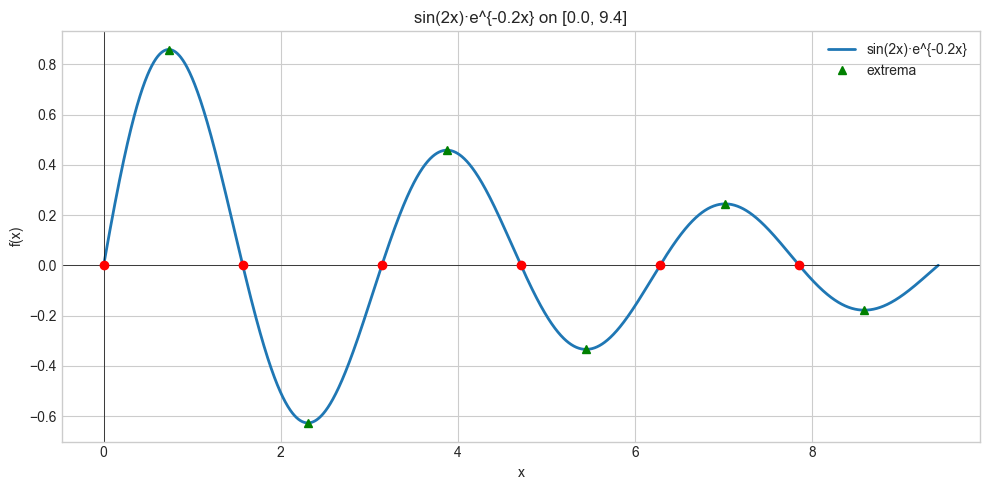

In [3]:
# --- Mini Project: Reusable function plotter with feature annotation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

class FunctionPlotter:
    """Interactive-style plotter with auto annotation."""
    
    def __init__(self, f, x_min, x_max, name='f(x)', n=2000):
        self.f = f
        self.x_min = x_min
        self.x_max = x_max
        self.name = name
        self.n = n
        self.x = np.linspace(x_min, x_max, n)
        with np.errstate(invalid='ignore', divide='ignore'):
            self.y = f(self.x)
    
    def plot(self, ax=None, annotate=True):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        
        ax.plot(self.x, self.y, linewidth=2, label=self.name)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        
        if annotate:
            # Mark zeros
            sign = np.sign(self.y)
            sign_changes = np.where(np.diff(sign) != 0)[0]
            for idx in sign_changes:
                ax.plot(self.x[idx], 0, 'ro', markersize=6, zorder=5)
            
            # Mark approximate extrema
            dy = np.diff(self.y)
            ext_idx = np.where(np.diff(np.sign(dy)) != 0)[0] + 1
            ax.plot(self.x[ext_idx], self.y[ext_idx], 'g^', markersize=6, zorder=5,
                    label='extrema')
        
        ax.set_title(f'{self.name} on [{self.x_min:.1f}, {self.x_max:.1f}]')
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.legend()
        return ax

# Demo
plotter = FunctionPlotter(lambda x: np.sin(2*x) * np.exp(-0.2*x), 0, 3*np.pi, 'sin(2x)·e^{-0.2x}')
fig, ax = plt.subplots(figsize=(10, 5))
plotter.plot(ax)
plt.tight_layout()
plt.show()

---

## 6. Experiments

**Experiment 1:** Plot f(x) = x^n for n = 1, 2, 3, 4, 5 on [-2, 2]. Observe how parity (even/odd n) determines symmetry. Try changing n to negative values.

**Experiment 2:** Compare f(x) = e^x and g(x) = x^10 on [0, 20]. Which dominates for large x? Try changing the exponent in g.

---

## 7. Exercises

**Easy 1.** Plot f(x) = (x-1)(x-2)(x-3) and identify its zeros from the graph. Verify analytically. *(Expected: zeros at 1, 2, 3)*

**Easy 2.** Write `is_even(f, test_range)` that checks if f(-x) ≈ f(x) for all x in test_range. Test on x², x³, cos(x), sin(x). *(Expected: x², cos are even; x³, sin are odd)*

**Medium 1.** Build a function `annotated_plot(f, a, b)` that plots f and automatically marks zero crossings with red circles and extrema with green triangles.

**Medium 2.** Plot the same function on three different x-ranges: [-0.1, 0.1], [-10, 10], [-1000, 1000] for f(x) = sin(x)/x. Describe how the visual impression changes.

**Hard.** Implement a function sniffer that automatically chooses a good x-range for plotting an arbitrary function: sample 100 points from [-100, 100], detect where the function is finite and varying, then zoom into the 'interesting' region.

---

## 8. Mini Project

*(See Section 5 for full implementation. Extend by modifying parameters.)*

---

## 9. Chapter Summary & Connections

- Visualization reveals zeros, extrema, asymptotes, and monotonicity faster than algebra
- `matplotlib` with labeled axes and titles is the standard tool
- Even/odd symmetry is detectable visually and computationally
- Feature detection (zeros, extrema) requires sign-change analysis

**Forward connections:**
- In ch099 (Distance Between Points), we will visualize 2D functions as surface plots
- Visualization tools built here scale directly to ch213 (Gradient Descent) where we plot loss landscapes
- The extrema detection approach here is the visual precursor to derivatives in ch205